# Lab 6: Motion and Image Recognition

In [1]:
import cv2
import numpy as np
import os

dataDir = './images'

### 1. Optical Flow with Lucas-Kanade Algorithm

In [2]:
# Define a VideoCapture Object
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Cannot open camera")
    exit()

# Define maximum number of features to track
max_num_features = 100

# Create some random colors
color = np.random.randint(0, 255, (max_num_features, 3))

# Take first frame and find corners in it
ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, maxCorners=max_num_features, qualityLevel=0.3, minDistance=7, blockSize=7)

# Create a mask image for drawing purposes
mask = np.zeros_like(old_frame)
 
while True:
    ret, frame = cap.read()
    if not ret:
        print("Can't receive frame...")
        break
 
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
 
    # Calculate optical flow
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, winSize=(15, 15), maxLevel=2, criteria=(cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_COUNT, 10, 0.03))
 
    # Select good points
    if p1 is not None:
        good_new = p1[st==1]
        good_old = p0[st==1]
 
    # Draw the tracks
    for i, (new, old) in enumerate(zip(good_new, good_old)):
        a, b = new.ravel()
        c, d = old.ravel()
        mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), color[i].tolist(), 2)
        frame = cv2.circle(frame, (int(a), int(b)), 5, color[i].tolist(), -1)
    img = cv2.add(frame, mask)
 
    cv2.imshow('frame', img)
    if cv2.waitKey(1) != -1:
        break
 
    # Now update the previous frame and previous points
    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)

cap.release()
cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/rui/Documentos/Faculdade/VC/myenv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/rui/Documentos/Faculdade/VC/myenv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/rui/Documentos/Faculdade/VC/myenv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/rui/Documentos/Faculdade/VC/myenv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFon

**Exercise 1.1**: Replace ShiTomasi feature detection by FAST feature detector.

In [3]:
# Define a VideoCapture Object (0 is usually the built-in webcam)
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Cannot open camera")
    exit()

# Define maximum number of features to track
max_num_features = 100

# Create some random colors
color = np.random.randint(0, 255, (max_num_features, 3))

# Take first frame and find corners in it
ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

# Initialize the FAST detector
fast = cv2.FastFeatureDetector_create()

# Detect keypoints in the first frame
kp = fast.detect(old_gray, None)

# Sort keypoints by quality (response) and keep only the top 'max_num_features'
kp = sorted(kp, key=lambda x: -x.response)[:max_num_features]

# Convert KeyPoint objects to a NumPy array of shape (N, 1, 2) for Lucas-Kanade
if len(kp) > 0:
    p0 = np.float32([k.pt for k in kp]).reshape(-1, 1, 2)
else:
    p0 = None

# Create a mask image for drawing purposes
mask = np.zeros_like(old_frame)

while True:
    ret, frame = cap.read()
    if not ret:
        print("Can't receive frame...")
        break
 
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
 
    # Only try to calculate optical flow if we actually have points to track!
    if p0 is not None and len(p0) > 0:
        # Calculate optical flow
        p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, winSize=(15, 15), maxLevel=2, criteria=(cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_COUNT, 10, 0.03))
     
        # Select good points (st == 1 means the point was successfully tracked to the next frame)
        if p1 is not None:
            good_new = p1[st==1]
            good_old = p0[st==1]
     
        # Draw the tracks
        for i, (new, old) in enumerate(zip(good_new, good_old)):
            a, b = new.ravel()
            c, d = old.ravel()
            mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), color[i].tolist(), 2)
            frame = cv2.circle(frame, (int(a), int(b)), 5, color[i].tolist(), -1)
            
        # Update the previous points for the next iteration
        p0 = good_new.reshape(-1, 1, 2)
        
    img = cv2.add(frame, mask)
 
    cv2.imshow('frame', img)
    # Press any key to exit the loop (or wait for the video to end)
    if cv2.waitKey(1) != -1:
        break
 
    # Now update the previous frame
    old_gray = frame_gray.copy()

cap.release()
cv2.destroyAllWindows()

# 2. Image Recognition

In this notebook, we build an image classification pipeline using HOG (Histogram of Oriented Gradients) for feature extraction and SVM for classification. By the end of the lab, students should be able to extract HOG features from images, train and evaluate classifiers using OpenCV's `cv2.ml` module and `scikit-learn`, and compare different approaches in terms of accuracy.


In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

### Loading and Exploring the Dataset

We will use the [MNIST](https://en.wikipedia.org/wiki/MNIST_database) handwritten digit dataset, which contains 70,000 grayscale images of digits (0–9), each of size 28×28 pixels.

In [6]:
# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Extract images and labels
images = mnist.data.astype(np.uint8)
labels = mnist.target.astype(np.int32)

print(f"Dataset size: {images.shape[0]} images")
print(f"Image vector length: {images.shape[1]} (i.e. {int(np.sqrt(images.shape[1]))}x{int(np.sqrt(images.shape[1]))} pixels)")
print(f"Labels: {np.unique(labels)}")

Dataset size: 70000 images
Image vector length: 784 (i.e. 28x28 pixels)
Labels: [0 1 2 3 4 5 6 7 8 9]


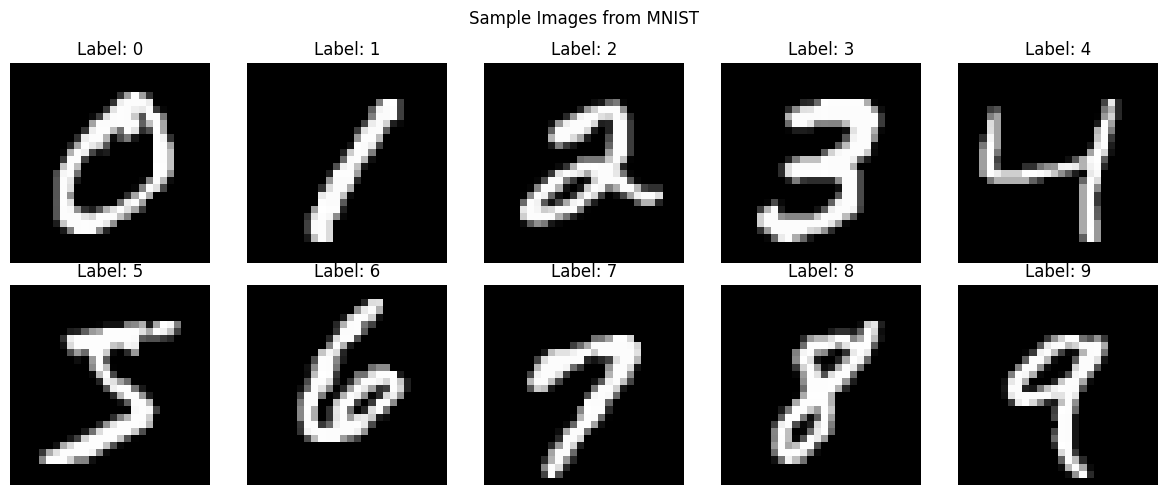

In [10]:
# Reshape flat vectors back into 28x28 images
images_2d = images.reshape(-1, 28, 28)

# Visualize some samples from the dataset
f, axarr = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    # Find the first occurrence of each digit
    idx = np.where(labels == i)[0][0]
    ax = axarr[i // 5, i % 5]
    ax.imshow(images_2d[idx], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"Label: {labels[idx]}")
    ax.axis("off")
plt.suptitle("Sample Images from MNIST")
plt.tight_layout()

In [43]:
# Use a subset to speed up training (10,000 samples)
subset_size = 10000
images_subset = images_2d[:subset_size]
labels_subset = labels[:subset_size]

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    images_subset, labels_subset, test_size=0.2, random_state=42, stratify=labels_subset
)

print(f"Training set: {X_train.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")

Training set: 8000 images
Test set: 2000 images


### Feature Extraction with HOG

The [Histogram of Oriented Gradients (HOG)](https://en.wikipedia.org/wiki/Histogram_of_oriented_gradients) descriptor captures the distribution of gradient orientations in localized regions of an image. It is widely used for object detection and image classification.

Key parameters:
* **winSize**: the size of the detection window (must match the image size)
* **blockSize**: the size of the block used for normalization
* **blockStride**: the stride between adjacent blocks
* **cellSize**: the size of each cell in which gradient histograms are computed
* **nbins**: the number of orientation bins in the histogram

In [44]:
# Define HOG descriptor parameters
winSize = (28, 28)
blockSize = (14, 14)
blockStride = (7, 7)
cellSize = (7, 7)
nbins = 9

# Create the HOG descriptor
hog = cv2.HOGDescriptor(winSize, blockSize, blockStride, cellSize, nbins)

# Compute HOG descriptor for a single image to inspect its shape
sample_descriptor = hog.compute(X_train[0])
print(f"HOG descriptor length: {sample_descriptor.shape[0]}")

HOG descriptor length: 324


In [45]:
def compute_hog_features(images, hog_descriptor):
    """Compute HOG features for a set of images."""
    hog_features = []
    for img in images:
        descriptor = hog_descriptor.compute(img)
        hog_features.append(descriptor.flatten())
    return np.array(hog_features, dtype=np.float32)

# Compute HOG features for training and test sets
print("Computing HOG features for training set...")
X_train_hog = compute_hog_features(X_train, hog)

print("Computing HOG features for test set...")
X_test_hog = compute_hog_features(X_test, hog)

print(f"Training HOG features shape: {X_train_hog.shape}")
print(f"Test HOG features shape: {X_test_hog.shape}")

Computing HOG features for training set...
Computing HOG features for test set...
Training HOG features shape: (8000, 324)
Test HOG features shape: (2000, 324)


### Training an SVM Classifier

We will use OpenCV's [SVM](https://docs.opencv.org/4.x/d1/d2d/classcv_1_1ml_1_1SVM.html) implementation to train a classifier on the HOG features.

The Support Vector Machine (SVM) finds an optimal hyperplane that separates the data in feature space. Key parameters:
* **Kernel type**: defines how the data is mapped to a higher-dimensional space (e.g., LINEAR, RBF)
* **C**: regularization parameter that controls the trade-off between margin width and classification errors

In [46]:
# Create and configure the SVM
svm = cv2.ml.SVM_create()
svm.setType(cv2.ml.SVM_C_SVC)
svm.setKernel(cv2.ml.SVM_LINEAR)
svm.setC(2.67)

# Train the SVM on HOG features
print("Training SVM...")
svm.train(X_train_hog, cv2.ml.ROW_SAMPLE, y_train)
print("Training complete!")

Training SVM...
Training complete!


### Evaluation

In [47]:
# Predict on the test set
_, y_pred = svm.predict(X_test_hog)
y_pred = y_pred.flatten().astype(np.int32)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 97.95%


In [48]:
# Display the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       200
           1       0.97      1.00      0.98       225
           2       0.98      0.97      0.98       198
           3       0.99      0.95      0.97       206
           4       0.96      0.97      0.97       196
           5       0.98      0.99      0.99       173
           6       0.99      0.99      0.99       203
           7       0.98      0.99      0.99       214
           8       0.97      0.98      0.98       189
           9       0.97      0.96      0.97       196

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



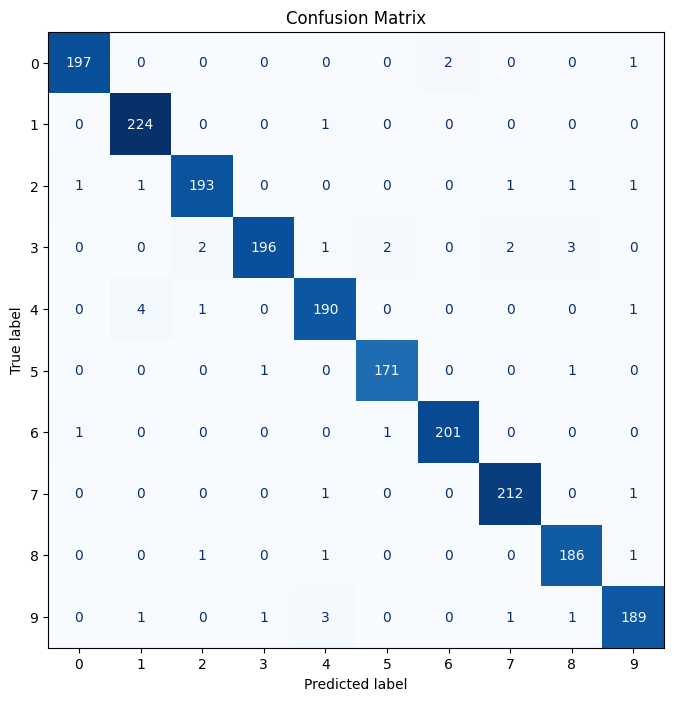

In [31]:
# Compute and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))

f, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
_ = ax.set_title("Confusion Matrix")

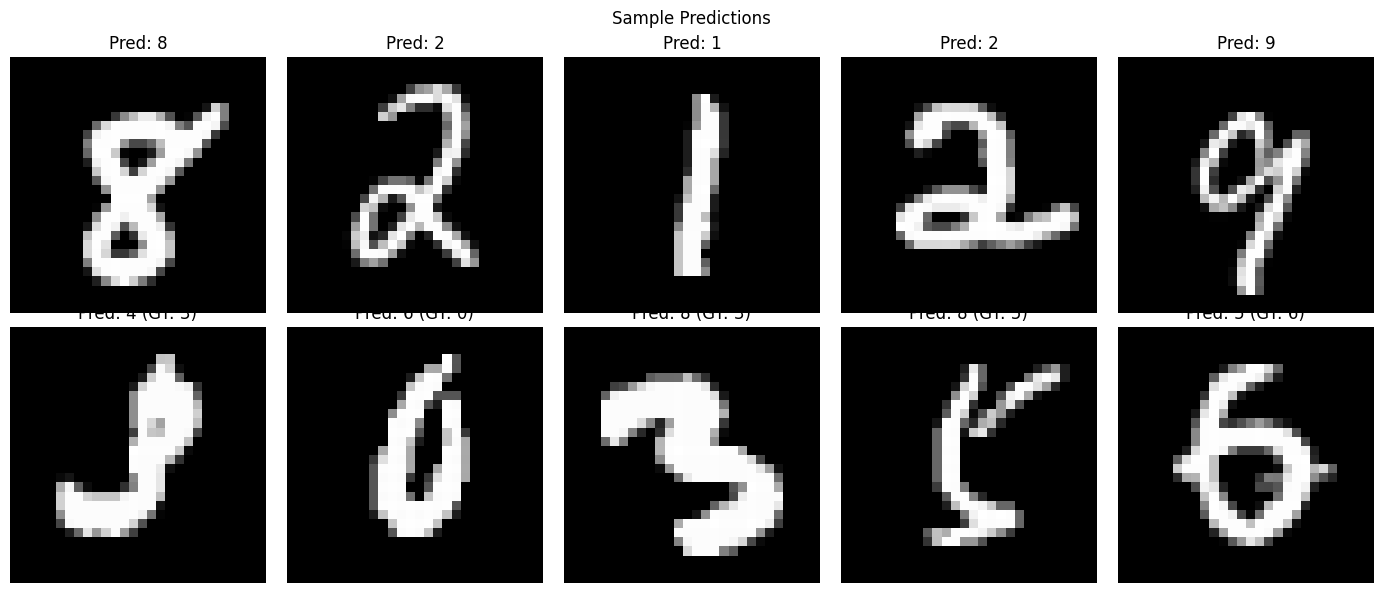

In [35]:
# Visualize some correct and incorrect predictions
correct = np.where(y_pred == y_test)[0]
incorrect = np.where(y_pred != y_test)[0]

f, axarr = plt.subplots(2, 5, figsize=(14, 6))

# Show 5 correct predictions
for i in range(5):
    idx = correct[i]
    axarr[0, i].imshow(X_test[idx], cmap='gray', vmin=0, vmax=255)
    axarr[0, i].set_title(f"Pred: {y_pred[idx]}")
    axarr[0, i].axis("off")
axarr[0, 0].set_ylabel("Correct", fontsize=12)

# Show 5 incorrect predictions
for i in range(5):
    idx = incorrect[i]
    axarr[1, i].imshow(X_test[idx], cmap='gray', vmin=0, vmax=255)
    axarr[1, i].set_title(f"Pred: {y_pred[idx]} (GT: {y_test[idx]})")
    axarr[1, i].axis("off")
axarr[1, 0].set_ylabel("Incorrect", fontsize=12)

plt.suptitle("Sample Predictions")
plt.tight_layout()

### Exercises

**Exercise 2.1**: Train the SVM using raw pixel values (flattened 28×28 images) as features instead of HOG descriptors. Compare the accuracy with the HOG-based approach.

**Tip**: Normalize the pixel values to the range [0, 1] by dividing by 255 before training.

In [37]:
# Flatten the 28x28 images back into straight 1D arrays of 784 pixels
# We use reshape(number_of_images, -1) so NumPy calculates the 784 automatically
X_train_raw = X_train.reshape(X_train.shape[0], -1)
X_test_raw = X_test.reshape(X_test.shape[0], -1)

# Normalization
# Convert to float32 (mandatory for OpenCV) and divide by 255
# This scales all pixel values to the range [0.0 (Black), 1.0 (White)]
X_train_raw = np.float32(X_train_raw) / 255.0
X_test_raw = np.float32(X_test_raw) / 255.0

print(f"Raw Pixels shape: {X_train_raw.shape} (784 features per image)")

# Create a NEW SVM so we don't overwrite the one we trained with HOG
svm_raw = cv2.ml.SVM_create()
svm_raw.setType(cv2.ml.SVM_C_SVC)
svm_raw.setKernel(cv2.ml.SVM_LINEAR)
svm_raw.setC(2.67)

# Train the model using raw pixels
svm_raw.train(X_train_raw, cv2.ml.ROW_SAMPLE, y_train)

# Predict on the test set
_, y_pred_raw = svm_raw.predict(X_test_raw)
y_pred_raw = y_pred_raw.flatten().astype(np.int32)

# Calculate and compare accuracy
accuracy_raw = accuracy_score(y_test, y_pred_raw)

print("-" * 40)
print(f"Test Accuracy (HOG): {accuracy * 100:.2f}%") 
print(f"Test Accuracy (Raw Pixels): {accuracy_raw * 100:.2f}%")
print("-" * 40)

Raw Pixels shape: (8000, 784) (784 features per image)
----------------------------------------
Test Accuracy (HOG): 97.95%
Test Accuracy (Raw Pixels): 91.50%
----------------------------------------


**Exercise 2.2**: Investigate the impact of the training set size on the model's performance. Train the SVM with 1,000, 5,000, 10,000, and 20,000 samples and plot the test accuracy as a function of the number of training samples.

**Tip**: Use `matplotlib` to create a line plot of the results.

Training SVM with 1000 samples...
Accuracy for 1000 samples: 96.10%

Training SVM with 5000 samples...
Accuracy for 5000 samples: 97.95%

Training SVM with 10000 samples...
Accuracy for 10000 samples: 98.38%

Training SVM with 20000 samples...
Accuracy for 20000 samples: 98.55%



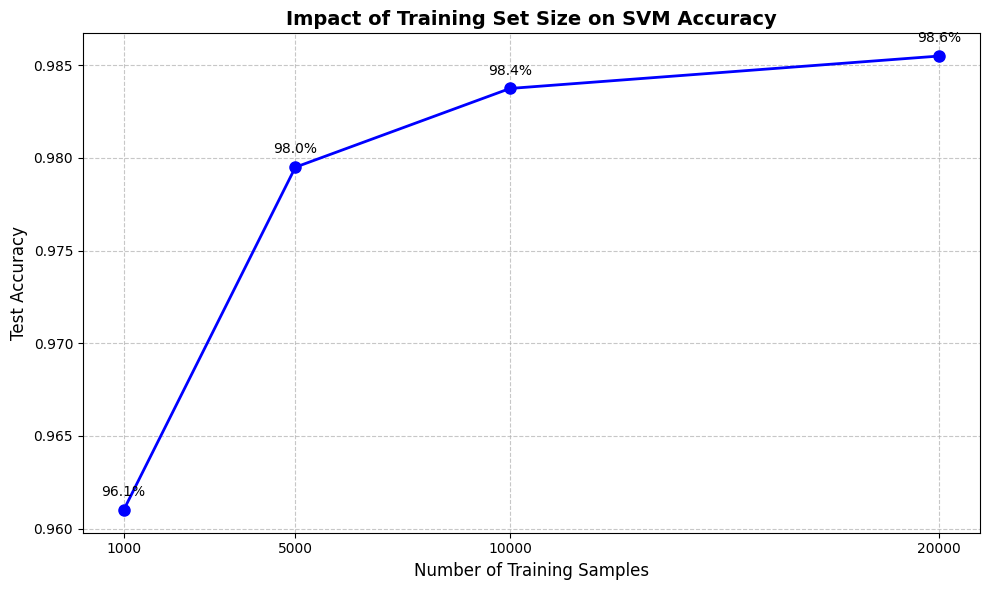

In [42]:
train_sizes = [1000, 5000, 10000, 20000]
accuracies = []

# To make the comparison fair (and fast!), we use a FIXED Test Set.
# We need a total of 24,000 samples (20,000 for the max training + 4,000 for testing)
total_samples = 24000
images_subset = images_2d[:total_samples]
labels_subset = labels[:total_samples]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    images_subset, labels_subset, test_size=4000, random_state=42, stratify=labels_subset
)

# Compute HOG features for the max datasets ONLY ONCE to save time
X_train_hog_full = compute_hog_features(X_train_full, hog)
X_test_hog_full = compute_hog_features(X_test_full, hog)

for size in train_sizes:
    print(f"Training SVM with {size} samples...")
    
    # Slice the training data to the current size requested by the loop
    X_train_sub = X_train_hog_full[:size]
    y_train_sub = y_train_full[:size]
    
    # Create a fresh SVM for each iteration
    svm_size = cv2.ml.SVM_create()
    svm_size.setType(cv2.ml.SVM_C_SVC)
    svm_size.setKernel(cv2.ml.SVM_LINEAR)
    svm_size.setC(2.67)
    
    svm_size.train(X_train_sub, cv2.ml.ROW_SAMPLE, y_train_sub)
    
    # Predict on the FIXED test set
    _, y_pred_size = svm_size.predict(X_test_hog_full)
    y_pred_size = y_pred_size.flatten().astype(np.int32)
    
    acc = accuracy_score(y_test_full, y_pred_size)
    accuracies.append(acc)
    print(f"Accuracy for {size} samples: {acc * 100:.2f}%\n")

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, accuracies, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

plt.title('Impact of Training Set Size on SVM Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Number of Training Samples', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(train_sizes) # Force X-axis to show our exact dataset sizes

# Add the exact percentage values on top of each dot
for i, txt in enumerate(accuracies):
    plt.annotate(f"{txt*100:.1f}%", (train_sizes[i], accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

**Exercise 2.3**: Apply image preprocessing before extracting HOG features. Try the following and compare results:
* Apply Gaussian blur with a 3×3 kernel
* Resize the images to 32×32 pixels (remember to adjust `winSize` in the HOG descriptor accordingly)
* Apply histogram equalization using `cv2.equalizeHist()`

In [66]:
def evaluate_preprocessing(name, preprocess_fn, hog_desc, X_tr, y_tr, X_te, y_te):
    print(f"--- Testing: {name} ---")
    
    # Apply the specific preprocessing function to all images
    # X_tr and X_te are lists of 2D images (28x28)
    X_tr_prep = [preprocess_fn(img) for img in X_tr]
    X_te_prep = [preprocess_fn(img) for img in X_te]
    
    print("Computing HOG...")
    X_tr_hog = compute_hog_features(X_tr_prep, hog_desc)
    X_te_hog = compute_hog_features(X_te_prep, hog_desc)
    
    print("Training SVM...")
    svm = cv2.ml.SVM_create()
    svm.setType(cv2.ml.SVM_C_SVC)
    svm.setKernel(cv2.ml.SVM_LINEAR)
    svm.setC(2.67)
    svm.train(X_tr_hog, cv2.ml.ROW_SAMPLE, y_tr)
    
    # Predict and calculate accuracy
    _, y_pred = svm.predict(X_te_hog)
    y_pred = y_pred.flatten().astype(np.int32)
    acc = accuracy_score(y_te, y_pred)
    
    print(f"Done! Accuracy: {acc * 100:.2f}%\n")
    return acc

# ==========================================
# DEFINING THE 3 PREPROCESSING TECHNIQUES
# ==========================================

# Gaussian Blur (3x3 kernel)
def apply_blur(img):
    return cv2.GaussianBlur(img, (3, 3), 0)

# Resize to 32x32
def apply_resize(img):
    return cv2.resize(img, (32, 32))

# Histogram Equalization
def apply_equalize(img):
    return cv2.equalizeHist(img)

# ==========================================
# SETUP HOG DESCRIPTORS
# ==========================================

# Original HOG (for Blur and Equalize, since they keep the 28x28 size)
hog_original = cv2.HOGDescriptor((28, 28), (14, 14), (7, 7), (7, 7), 9)

# New HOG for the 32x32 images
# We must adjust the grid to be proportional. 16x16 blocks and 8x8 cells fit perfectly in 32x32.
hog_32 = cv2.HOGDescriptor((32, 32), (16, 16), (8, 8), (8, 8), 9)

# ==========================================
# RUN THE EXPERIMENTS
# ==========================================

acc_blur = evaluate_preprocessing("Gaussian Blur (3x3)", apply_blur, hog_original, X_train, y_train, X_test, y_test)
acc_resize = evaluate_preprocessing("Resize to 32x32", apply_resize, hog_32, X_train, y_train, X_test, y_test)
acc_eq = evaluate_preprocessing("Histogram Equalization", apply_equalize, hog_original, X_train, y_train, X_test, y_test)

print("=== FINAL LEADERBOARD ===")
print(f"Baseline HOG (No Prep): ~97.95% (Reference)")
print(f"Gaussian Blur:          {acc_blur * 100:.2f}%")
print(f"Resize (32x32):         {acc_resize * 100:.2f}%")
print(f"Histogram Equalization: {acc_eq * 100:.2f}%")
print("=========================")

--- Testing: Gaussian Blur (3x3) ---
Computing HOG...
Training SVM...
Done! Accuracy: 98.20%

--- Testing: Resize to 32x32 ---
Computing HOG...
Training SVM...
Done! Accuracy: 97.90%

--- Testing: Histogram Equalization ---
Computing HOG...
Training SVM...
Done! Accuracy: 97.90%

=== FINAL LEADERBOARD ===
Baseline HOG (No Prep): ~97.95% (Reference)
Gaussian Blur:          98.20%
Resize (32x32):         97.90%
Histogram Equalization: 97.90%


**Exercise 2.4**: Implement a simple test by drawing a digit on a blank 28×28 image and classifying it with the trained model.

**Tips**:
* Create a blank image with `np.zeros((28, 28), dtype=np.uint8)`
* Use `cv2.line()`, `cv2.circle()`, or `cv2.putText()` to draw a digit
* Compute the HOG descriptor and use `svm.predict()` to classify it

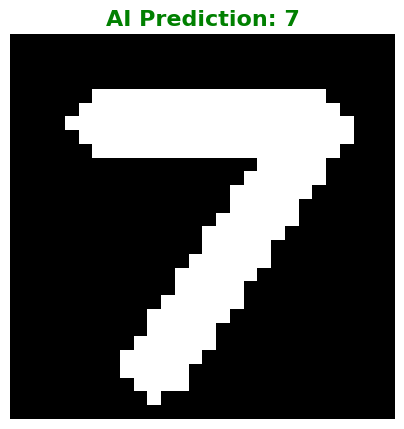

In [69]:
# Create a blank 28x28 black image (dtype=np.uint8 is crucial for images)
custom_digit = np.zeros((28, 28), dtype=np.uint8)

# Draw a '7' using two lines
# cv2.line(image, start_point, end_point, color (255=white), thickness)
cv2.line(custom_digit, (6, 6), (22, 6), 255, 3)   # Top horizontal line
cv2.line(custom_digit, (22, 6), (10, 24), 255, 3) # Diagonal line going down

# Compute the HOG descriptor for our custom image
custom_hog = hog_original.compute(custom_digit).flatten()

# The SVM ALWAYS expects a 2D array (a list of samples), even if it's just one image.
# We must reshape our single sample to have 1 row and 324 columns (1, -1)
custom_hog_2d = np.float32(custom_hog).reshape(1, -1)

_, prediction = svm.predict(custom_hog_2d)
predicted_label = int(prediction[0][0])

plt.figure(figsize=(5, 5))
plt.imshow(custom_digit, cmap='gray', vmin=0, vmax=255)
plt.title(f"AI Prediction: {predicted_label}", fontsize=16, fontweight='bold', color='green')
plt.axis("off")
plt.show()

### Additional challenge

Replace the SVM classifier with a different OpenCV ML model and compare the results. Try one or both of the following:
* [KNN](https://docs.opencv.org/4.x/dd/de1/classcv_1_1ml_1_1KNearest.html) (`cv2.ml.KNearest_create()`): set the default number of neighbours with `setDefaultK()` and train with `train()`. Experiment with different values of K (e.g., 3, 5, 7).
* [MLP (Multilayer Perceptron)](https://docs.opencv.org/4.x/d0/dce/classcv_1_1ml_1_1ANN__MLP.html) (`cv2.ml.ANN_MLP_create()`): define the network architecture with `setLayerSizes()` (e.g., input layer matching the HOG descriptor length, one hidden layer with 128 neurons, and an output layer with 10 neurons). Set the activation function with `setActivationFunction()` and the training method with `setTrainMethod()`.

Compare the test accuracy with the SVM baseline.

**Tips**:
* Both classifiers use the same `train()` and `predict()` interface as `cv2.ml.SVM`
* For the MLP, labels must be provided as a one-hot encoded matrix (e.g., label 3 → `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`). Use `np.eye(10)[labels]` to convert.
* For the MLP, `predict()` returns continuous values for each class — use `np.argmax()` on each row to obtain the predicted label

In [89]:
# ==========================================
# K-NEAREST NEIGHBORS (KNN)
# ==========================================
print("Training KNN...")
knn = cv2.ml.KNearest_create()
K_VALUE = 5
knn.setDefaultK(K_VALUE)
knn.setIsClassifier(True)

# OpenCV's KNN expects labels to be float32 for training
knn.train(X_train_hog, cv2.ml.ROW_SAMPLE, np.float32(y_train))

# Predict and evaluate
_, y_pred_knn_raw = knn.predict(X_test_hog)
y_pred_knn = y_pred_knn_raw.flatten().astype(np.int32)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc_knn * 100:.2f}%\n")

# ==========================================
# MULTILAYER PERCEPTRON (MLP - NEURAL NETWORK)
# ==========================================
print("Training MLP...")

# Define the network architecture: [Input (324), Hidden (128), Output (10)]
input_neurons = X_train_hog.shape[1] # 324 features from HOG
layer_sizes = np.array([input_neurons, 128, 10], dtype=np.int32)

mlp = cv2.ml.ANN_MLP_create()
mlp.setLayerSizes(layer_sizes)
mlp.setActivationFunction(cv2.ml.ANN_MLP_SIGMOID_SYM, 1, 1) # Sigmoid activation
mlp.setTrainMethod(cv2.ml.ANN_MLP_BACKPROP, 0.001, 0.1)     # Backpropagation
mlp.setTermCriteria((cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS, 300, 0.01))

# A neural network output layer has 10 neurons (one for each digit). 
# We need to translate '3' into [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train_onehot = np.eye(10, dtype=np.float32)[y_train]

# Train the network
mlp.train(X_train_hog, cv2.ml.ROW_SAMPLE, y_train_onehot)

# Predict
_, y_pred_mlp_raw = mlp.predict(X_test_hog)

# We use np.argmax() to find the index (0-9) of the neuron that "fired" the highest value
y_pred_mlp = np.argmax(y_pred_mlp_raw, axis=1).astype(np.int32)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"MLP Accuracy: {acc_mlp * 100:.2f}%\n")

print("=== CLASSIFIER SHOWDOWN (HOG FEATURES) ===")
print(f"1. SVM (Baseline): ~97.95%") 
print(f"2. KNN (K={K_VALUE}):      {acc_knn * 100:.2f}%")
print(f"3. MLP (128 units):{acc_mlp * 100:.2f}%")
print("==========================================")

Training KNN...
KNN Accuracy: 97.95%

Training MLP...
MLP Accuracy: 98.05%

=== CLASSIFIER SHOWDOWN (HOG FEATURES) ===
1. SVM (Baseline): ~97.95%
2. KNN (K=5):      97.95%
3. MLP (128 units):98.05%
